# 📊 Bitcoin Fear & Greed vs Trader Performance
### Hyperliquid Historical Trade Analysis

> **Assignment:** Explore the relationship between market sentiment and trader performance,  
> uncover hidden patterns, and deliver insights that can drive smarter trading strategies.

---

| Dataset | Rows | Description |
|---|---|---|
| `historical_data.csv` | 211,224 | Real trades from Hyperliquid exchange |
| `fear_greed_index.csv` | 2,644 | Daily Bitcoin Fear & Greed scores (2018–2025) |

**Key question:** Does market sentiment (Fear vs Greed) affect how traders behave and how much money they make?


## ⚙️ Step 0 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas matplotlib seaborn scipy plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──
BG    = "#0d0d18"
PANEL = "#13131f"
TEXT  = "#e8e8f0"
GRID  = "#1e1e32"

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "text.color":         TEXT,
    "axes.labelcolor":    TEXT,
    "xtick.color":        TEXT,
    "ytick.color":        TEXT,
    "axes.edgecolor":     GRID,
    "axes.facecolor":     PANEL,
    "figure.facecolor":   BG,
    "grid.color":         GRID,
    "grid.linewidth":     0.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## 📂 Step 1 — Load the Datasets

In [2]:
# ── Load both CSVs ──
# Make sure both files are in the same folder as this notebook
trader    = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

print(f"✅ Trader data    : {trader.shape[0]:,} rows × {trader.shape[1]} columns")
print(f"✅ Sentiment data : {sentiment.shape[0]:,} rows × {sentiment.shape[1]} columns")
print()
print("Trader columns   :", list(trader.columns))
print("Sentiment columns:", list(sentiment.columns))


✅ Trader data    : 211,224 rows × 16 columns
✅ Sentiment data : 2,644 rows × 4 columns

Trader columns   : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment columns: ['timestamp', 'value', 'classification', 'date']


### 👀 Quick Preview

In [3]:
print("── Trader Data (first 3 rows) ──")
display(trader.head(3))
print()
print("── Sentiment Data (first 3 rows) ──")
display(sentiment.head(3))


── Trader Data (first 3 rows) ──


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12



── Sentiment Data (first 3 rows) ──


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


## 🧹 Step 2 — Clean & Prepare Data

In [4]:
# ── Trader: parse date from 'Timestamp IST' (format: DD-MM-YYYY HH:MM) ──
trader['date'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True).dt.normalize()

# ── Convert numeric columns ──
for col in ['Closed PnL', 'Size USD', 'Size Tokens', 'Execution Price', 'Fee']:
    trader[col] = pd.to_numeric(trader[col], errors='coerce')

# ── Helper boolean columns ──
trader['is_long']   = trader['Side'].str.upper() == 'BUY'          # BUY = Long
trader['is_closed'] = trader['Closed PnL'] != 0                    # Trade exited
trader['is_win']    = trader['Closed PnL'] > 0                     # Profitable trade

# ── Sentiment: parse date ──
sentiment['date']  = pd.to_datetime(sentiment['date']).dt.normalize()
sentiment['value'] = pd.to_numeric(sentiment['value'], errors='coerce')

# ── Only closed trades for PnL analysis ──
closed = trader[trader['is_closed']].copy()

print(f"Total trades       : {len(trader):,}")
print(f"Open positions     : {(~trader['is_closed']).sum():,}  (Closed PnL = 0)")
print(f"Closed trades      : {len(closed):,}  (used for PnL analysis)")
print(f"Unique traders     : {trader['Account'].nunique()}")
print(f"Unique coins       : {trader['Coin'].nunique()}")
print(f"Trader date range  : {trader['date'].min().date()} → {trader['date'].max().date()}")
print(f"Sentiment date range: {sentiment['date'].min().date()} → {sentiment['date'].max().date()}")


Total trades       : 211,224
Open positions     : 106,816  (Closed PnL = 0)
Closed trades      : 104,408  (used for PnL analysis)
Unique traders     : 32
Unique coins       : 246
Trader date range  : 2023-05-01 → 2025-05-01
Sentiment date range: 2018-02-01 → 2025-05-02


## 🔗 Step 3 — Merge Datasets on Date

In [5]:
# ── Join trader trades with sentiment by date ──
merged = pd.merge(
    trader,
    sentiment[['date', 'value', 'classification']].drop_duplicates('date'),
    on='date',
    how='inner'
)

closed_m = merged[merged['is_closed']].copy()

# ── Sentiment order for charts ──
ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
COLORS = {
    "Extreme Fear":  "#e63946",
    "Fear":          "#f4a261",
    "Neutral":       "#adb5bd",
    "Greed":         "#52b788",
    "Extreme Greed": "#2dc653"
}
palette = [COLORS[s] for s in ORDER]

print(f"✅ Merged rows: {len(merged):,}")
print()
print("Sentiment distribution in merged data:")
print(merged['classification'].value_counts().reindex(ORDER))


✅ Merged rows: 211,218

Sentiment distribution in merged data:
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


## 📐 Step 4 — Compute Key Metrics by Sentiment

In [6]:
# ── All trades aggregated by sentiment ──
by_sent = merged.groupby('classification').agg(
    trade_count  = ('Closed PnL', 'count'),
    total_volume = ('Size USD',   'sum'),
    avg_size     = ('Size USD',   'mean'),
    total_pnl    = ('Closed PnL', 'sum'),
    avg_pnl      = ('Closed PnL', 'mean'),
    total_fees   = ('Fee',        'sum'),
    long_ratio   = ('is_long',    'mean'),
).reindex(ORDER)

# ── Closed trades only ──
by_sent_closed = closed_m.groupby('classification').agg(
    win_rate    = ('is_win',    'mean'),
    avg_pnl_c   = ('Closed PnL','mean'),
    total_pnl_c = ('Closed PnL','sum'),
).reindex(ORDER)

# ── Daily aggregation for correlation ──
daily = merged.groupby('date').agg(
    avg_pnl       = ('Closed PnL', 'mean'),
    sentiment_val = ('value',       'mean'),
    classification= ('classification','first')
).dropna()

# ── Print summary table ──
summary = pd.concat([by_sent, by_sent_closed], axis=1)
summary['win_rate_pct'] = (summary['win_rate'] * 100).round(1)
summary['long_pct']     = (summary['long_ratio'] * 100).round(1)
summary['vol_M']        = (summary['total_volume'] / 1e6).round(1)

display(summary[['trade_count','vol_M','win_rate_pct','avg_pnl_c','long_pct','total_fees']].rename(columns={
    'trade_count' : 'Trades',
    'vol_M'       : 'Volume ($M)',
    'win_rate_pct': 'Win Rate (%)',
    'avg_pnl_c'   : 'Avg PnL ($)',
    'long_pct'    : 'Long Ratio (%)',
    'total_fees'  : 'Total Fees ($)',
}))


,Trades,Volume ($M),Win Rate (%),Avg PnL ($),Long Ratio (%),Total Fees ($)
classification,,,,,,
Extreme Fear,21400,114.5,76.2,71.027316,51.1,23888.633939
Fear,61837,483.3,87.3,112.625988,49.0,92456.948674
Neutral,37686,180.2,82.4,71.199993,50.3,39374.268304
Greed,50303,288.6,76.9,85.403927,48.9,63098.691979
Extreme Greed,39992,124.5,89.2,130.205309,44.9,27030.665465


## 🔬 Step 5 — Statistical Correlation Test

In [7]:
# ── Pearson correlation: sentiment score vs average daily PnL ──
corr, pval = stats.pearsonr(daily['sentiment_val'], daily['avg_pnl'])

print("=" * 50)
print("  Pearson Correlation Test")
print("=" * 50)
print(f"  Sentiment Score  vs  Avg Daily PnL")
print(f"  r (correlation)  = {corr:.4f}")
print(f"  p-value          = {pval:.4f}")
print()
if pval < 0.05:
    direction = "positive" if corr > 0 else "negative"
    print(f"  ✅ Statistically significant {direction} correlation (p < 0.05)")
else:
    print("  ⚠️  Not statistically significant (p > 0.05)")
    print("  → Sentiment score alone does NOT reliably predict daily PnL")
    print("  → Trader skill matters more than market mood")
print("=" * 50)


  Pearson Correlation Test
  Sentiment Score  vs  Avg Daily PnL
  r (correlation)  = 0.0373
  p-value          = 0.4152

  ⚠️  Not statistically significant (p > 0.05)
  → Sentiment score alone does NOT reliably predict daily PnL
  → Trader skill matters more than market mood


## 📊 Step 6 — Visualisations

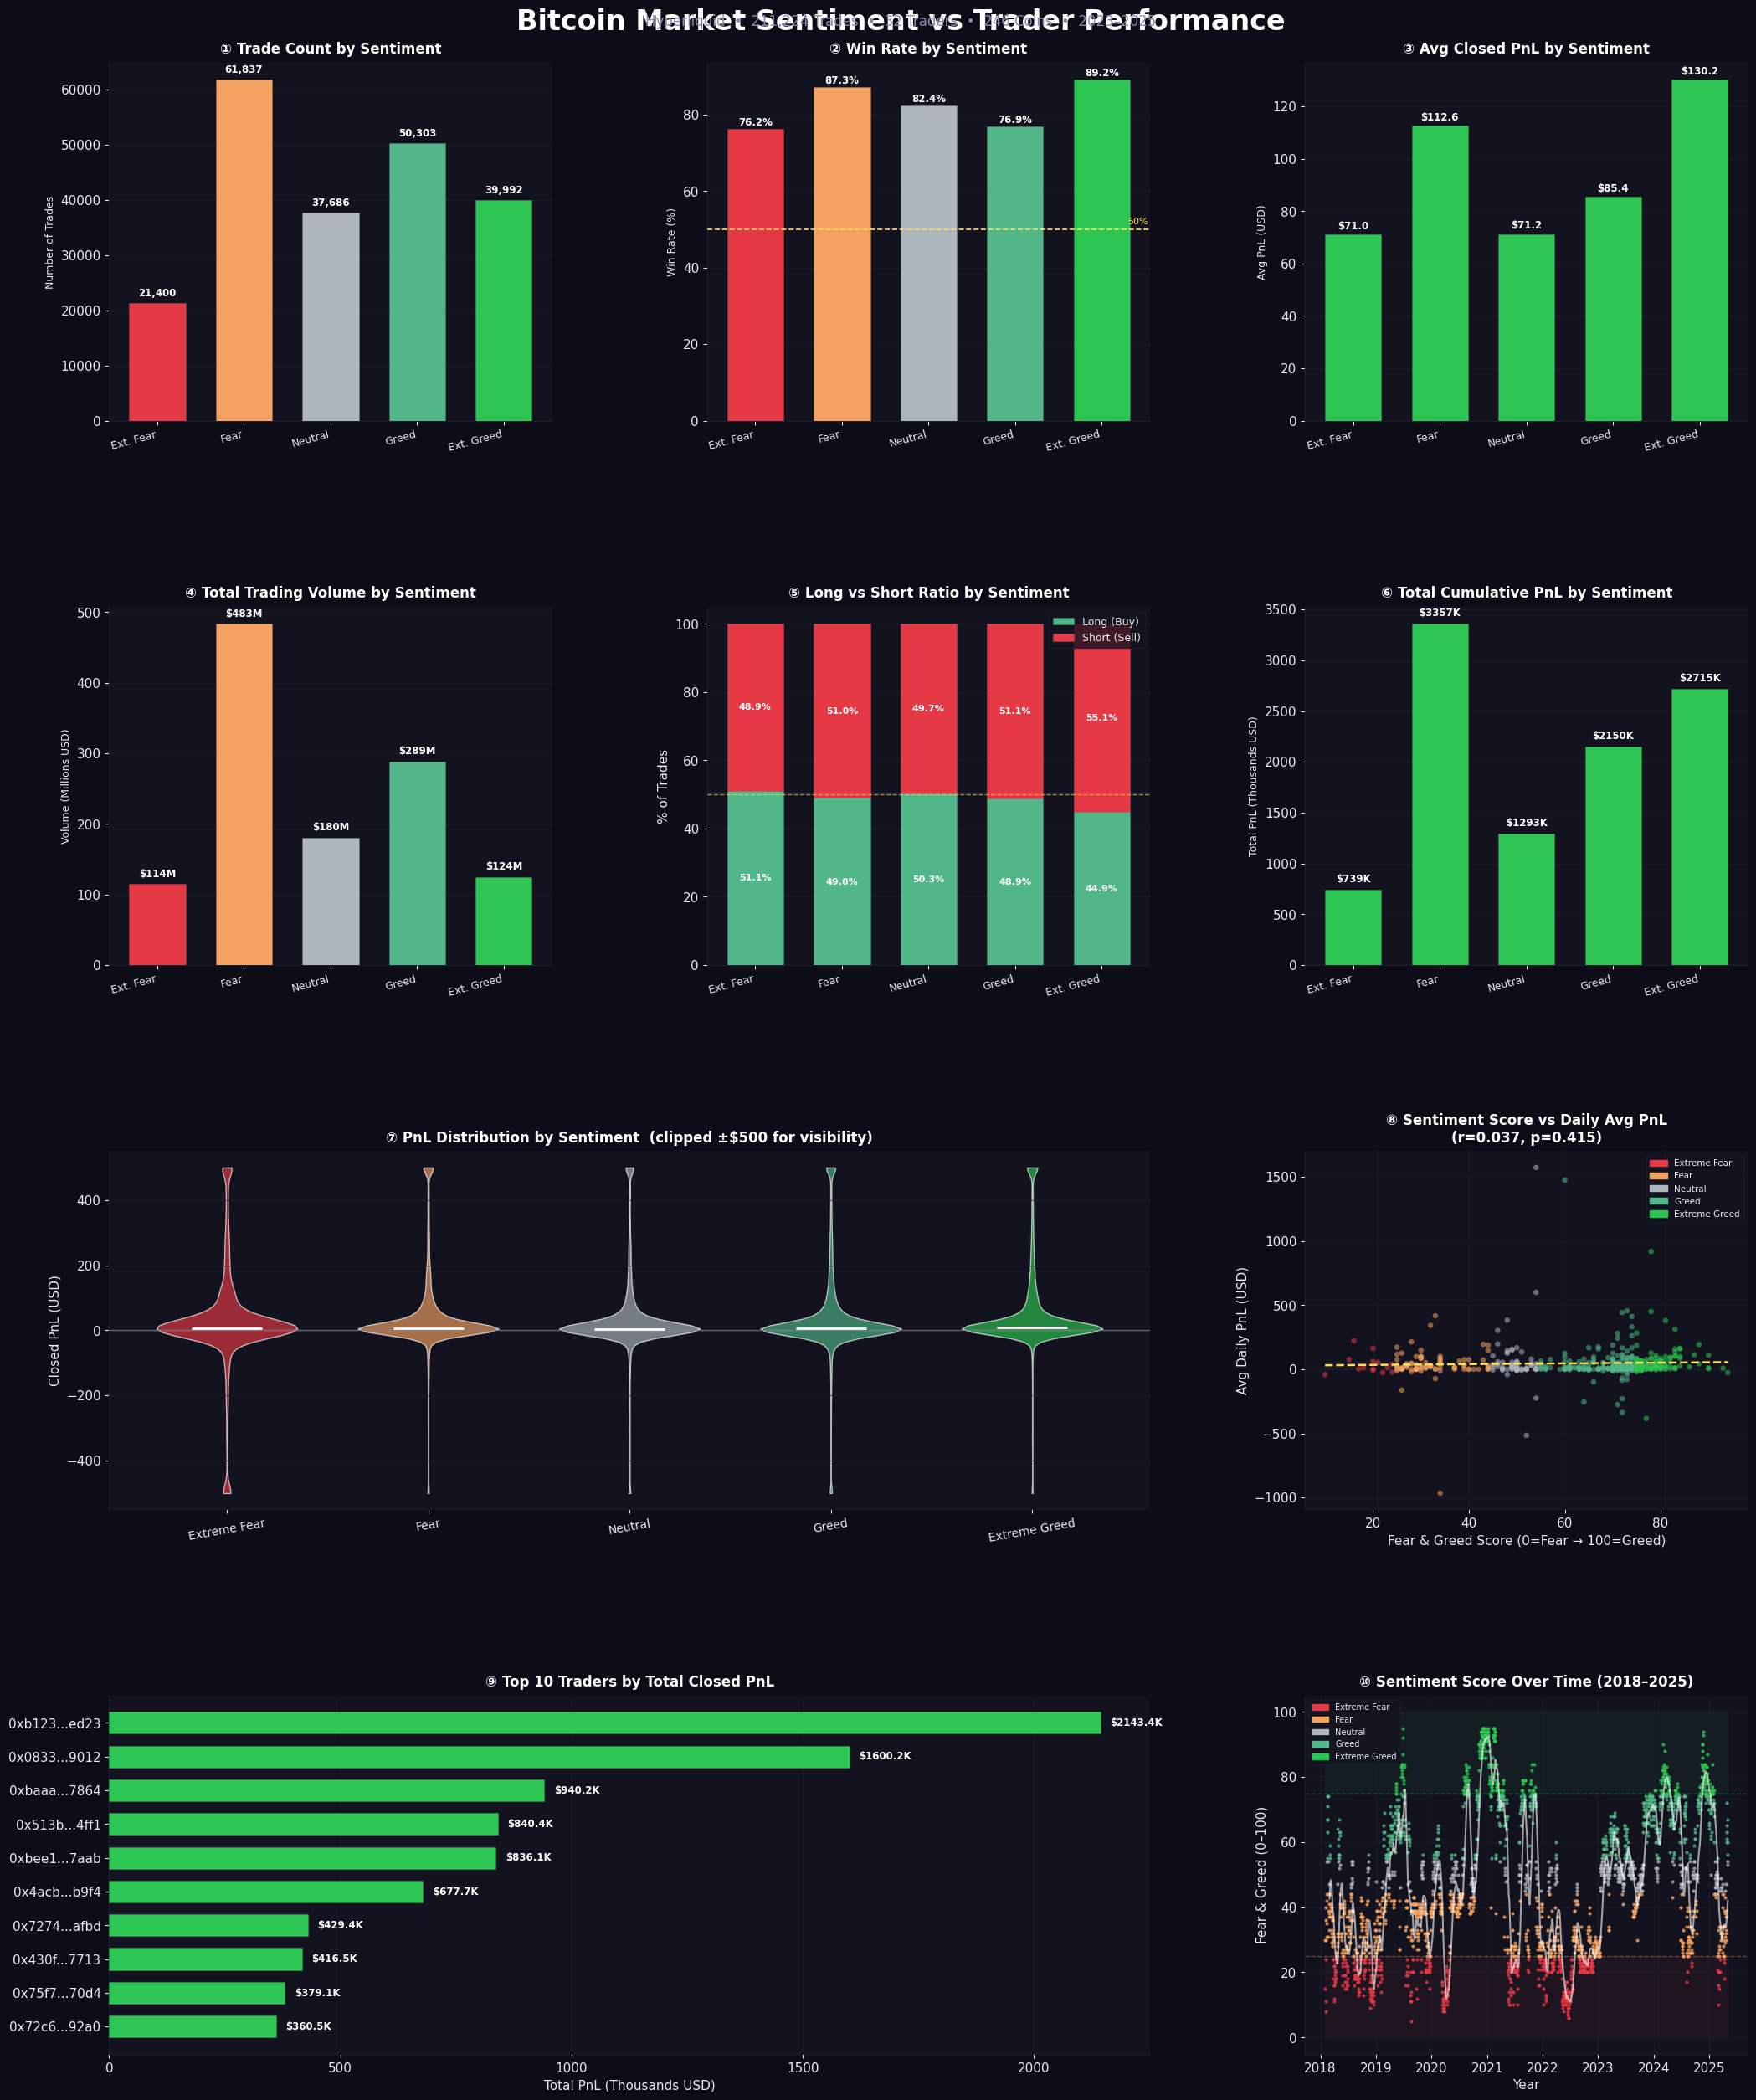

✅ Chart saved as trading_sentiment_analysis.png


In [8]:
SHORT = ["Ext. Fear", "Fear", "Neutral", "Greed", "Ext. Greed"]

def bar_chart(ax, vals, title, ylabel, colors=palette, fmt="{:.1f}", add_zero=True):
    x = np.arange(len(ORDER))
    bars = ax.bar(x, vals, color=colors, width=0.65,
                  edgecolor='#ffffff18', linewidth=0.6, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT, fontsize=9, rotation=15, ha='right')
    ax.set_title(title, fontsize=12, fontweight='bold', color='#ffffff', pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(axis='y', zorder=0)
    if add_zero:
        ax.axhline(0, color='#ffffff33', linewidth=0.8)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            offset = (max(vals) - min(vals)) * 0.02
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + offset,
                    fmt.format(v), ha='center', va='bottom',
                    fontsize=8.5, color='#ffffff', fontweight='bold')

fig = plt.figure(figsize=(22, 26), facecolor=BG)
fig.suptitle(
    "Bitcoin Market Sentiment vs Trader Performance",
    fontsize=24, fontweight='bold', color='#ffffff', y=0.98
)
fig.text(0.5, 0.972,
    "Hyperliquid  •  211,224 Trades  •  32 Traders  •  246 Coins  •  2023–2025",
    ha='center', fontsize=12, color='#8888aa'
)

gs = gridspec.GridSpec(4, 3, figure=fig,
    hspace=0.52, wspace=0.35,
    top=0.955, bottom=0.04, left=0.07, right=0.96)

# ── 1. Trade Count ──
ax1 = fig.add_subplot(gs[0, 0])
bar_chart(ax1, by_sent['trade_count'].values,
          "① Trade Count by Sentiment", "Number of Trades",
          fmt="{:,.0f}", add_zero=False)

# ── 2. Win Rate ──
ax2 = fig.add_subplot(gs[0, 1])
wr_vals = (by_sent_closed['win_rate'] * 100).values
bar_chart(ax2, wr_vals, "② Win Rate by Sentiment", "Win Rate (%)", fmt="{:.1f}%", add_zero=False)
ax2.axhline(50, color='#ffdd57', linewidth=1.2, linestyle='--', zorder=4)
ax2.text(4.3, 51.5, "50%", color='#ffdd57', fontsize=8)

# ── 3. Avg Closed PnL ──
ax3 = fig.add_subplot(gs[0, 2])
pnl_vals = by_sent_closed['avg_pnl_c'].values
pnl_colors = ['#2dc653' if v >= 0 else '#e63946' for v in pnl_vals]
bar_chart(ax3, pnl_vals, "③ Avg Closed PnL by Sentiment",
          "Avg PnL (USD)", colors=pnl_colors, fmt="${:.1f}")

# ── 4. Total Volume ──
ax4 = fig.add_subplot(gs[1, 0])
vol_vals = by_sent['total_volume'].values / 1e6
bar_chart(ax4, vol_vals, "④ Total Trading Volume by Sentiment",
          "Volume (Millions USD)", fmt="${:.0f}M", add_zero=False)

# ── 5. Long vs Short Stacked ──
ax5 = fig.add_subplot(gs[1, 1])
long_r  = by_sent['long_ratio'].values * 100
short_r = 100 - long_r
x = np.arange(len(ORDER))
ax5.bar(x, long_r,  color='#52b788', width=0.65, label='Long (Buy)',
        edgecolor='#ffffff18', zorder=3)
ax5.bar(x, short_r, color='#e63946', width=0.65, label='Short (Sell)',
        edgecolor='#ffffff18', bottom=long_r, zorder=3)
ax5.set_xticks(x); ax5.set_xticklabels(SHORT, fontsize=9, rotation=15, ha='right')
ax5.axhline(50, color='#ffdd5799', linewidth=1, linestyle='--', zorder=4)
ax5.set_title("⑤ Long vs Short Ratio by Sentiment",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax5.set_ylabel("% of Trades"); ax5.grid(axis='y', zorder=0)
ax5.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
for i, (l, s) in enumerate(zip(long_r, short_r)):
    ax5.text(i, l/2,     f"{l:.1f}%", ha='center', va='center', fontsize=8, color='#fff', fontweight='bold')
    ax5.text(i, l + s/2, f"{s:.1f}%", ha='center', va='center', fontsize=8, color='#fff', fontweight='bold')

# ── 6. Total PnL ──
ax6 = fig.add_subplot(gs[1, 2])
tpnl_vals   = by_sent_closed['total_pnl_c'].values / 1e3
tpnl_colors = ['#2dc653' if v >= 0 else '#e63946' for v in tpnl_vals]
bar_chart(ax6, tpnl_vals, "⑥ Total Cumulative PnL by Sentiment",
          "Total PnL (Thousands USD)", colors=tpnl_colors, fmt="${:.0f}K")

# ── 7. Violin: PnL Distribution ──
ax7 = fig.add_subplot(gs[2, 0:2])
plot_data = [
    closed_m[closed_m['classification'] == s]['Closed PnL'].dropna().clip(-500, 500).values
    for s in ORDER
]
vp = ax7.violinplot(plot_data, positions=range(len(ORDER)),
                    widths=0.7, showmedians=True, showextrema=False)
for body, color in zip(vp['bodies'], palette):
    body.set_facecolor(color); body.set_alpha(0.65); body.set_edgecolor('#ffffff33')
vp['cmedians'].set_color('#ffffff'); vp['cmedians'].set_linewidth(2)
ax7.set_xticks(range(len(ORDER))); ax7.set_xticklabels(ORDER, fontsize=10, rotation=10)
ax7.set_title("⑦ PnL Distribution by Sentiment  (clipped ±$500 for visibility)",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax7.set_ylabel("Closed PnL (USD)"); ax7.axhline(0, color='#ffffff55', linewidth=1)
ax7.grid(axis='y', zorder=0)

# ── 8. Scatter: Sentiment score vs daily avg PnL ──
ax8 = fig.add_subplot(gs[2, 2])
for s in ORDER:
    d = daily[daily['classification'] == s]
    ax8.scatter(d['sentiment_val'], d['avg_pnl'],
                color=COLORS[s], alpha=0.55, s=22, edgecolors='none', label=s, zorder=3)
m, b, r, p, _ = stats.linregress(daily['sentiment_val'], daily['avg_pnl'])
xs = np.linspace(daily['sentiment_val'].min(), daily['sentiment_val'].max(), 100)
ax8.plot(xs, m*xs+b, color='#ffdd57', linewidth=1.8, linestyle='--', zorder=4)
ax8.set_title(f"⑧ Sentiment Score vs Daily Avg PnL\n(r={r:.3f}, p={p:.3f})",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax8.set_xlabel("Fear & Greed Score (0=Fear → 100=Greed)")
ax8.set_ylabel("Avg Daily PnL (USD)"); ax8.grid(zorder=0)
handles = [mpatches.Patch(color=COLORS[s], label=s) for s in ORDER]
ax8.legend(handles=handles, facecolor=PANEL, edgecolor=GRID,
           labelcolor=TEXT, fontsize=7.5, loc='upper right')

# ── 9. Top 10 Traders ──
ax9 = fig.add_subplot(gs[3, 0:2])
top10 = closed_m.groupby('Account')['Closed PnL'].sum().sort_values(ascending=True).tail(10)
short_labels = [f"{a[:6]}...{a[-4:]}" for a in top10.index]
bar_colors2  = ['#2dc653' if v >= 0 else '#e63946' for v in top10.values]
bars9 = ax9.barh(short_labels, top10.values / 1e3, color=bar_colors2,
                 edgecolor='#ffffff18', height=0.65, zorder=3)
ax9.set_title("⑨ Top 10 Traders by Total Closed PnL",
              fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax9.set_xlabel("Total PnL (Thousands USD)")
ax9.axvline(0, color='#ffffff33', linewidth=0.8); ax9.grid(axis='x', zorder=0)
for bar, v in zip(bars9, top10.values/1e3):
    ax9.text(v + max(top10.values/1e3)*0.01,
             bar.get_y() + bar.get_height()/2,
             f"${v:.1f}K", va='center', fontsize=8.5, color='#ffffff', fontweight='bold')

# ── 10. Sentiment Over Time ──
ax10 = fig.add_subplot(gs[3, 2])
sent_time = sentiment.sort_values('date')
for s in ORDER:
    d = sent_time[sent_time['classification'] == s]
    ax10.scatter(d['date'], d['value'], color=COLORS[s], s=4, alpha=0.7, zorder=3)
ax10.plot(sent_time['date'], sent_time['value'].rolling(30).mean(),
          color='#ffffff', linewidth=1.5, alpha=0.6, zorder=4, label='30d MA')
ax10.axhline(25, color='#f4a26155', linewidth=1, linestyle='--')
ax10.axhline(75, color='#52b78855', linewidth=1, linestyle='--')
ax10.fill_between(sent_time['date'], 0,  25, alpha=0.06, color='#e63946')
ax10.fill_between(sent_time['date'], 75, 100, alpha=0.06, color='#2dc653')
ax10.set_title("⑩ Sentiment Score Over Time (2018–2025)",
               fontsize=12, fontweight='bold', color='#ffffff', pad=8)
ax10.set_ylabel("Fear & Greed (0–100)"); ax10.set_xlabel("Year")
handles2 = [mpatches.Patch(color=COLORS[s], label=s) for s in ORDER]
ax10.legend(handles=handles2, facecolor=PANEL, edgecolor=GRID,
            labelcolor=TEXT, fontsize=7, loc='upper left')
ax10.grid(zorder=0)

plt.savefig("../charts/trading_sentiment_analysis.png", dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Chart saved as trading_sentiment_analysis.png")


## 💡 Step 7 — Key Insights & Findings

In [9]:
print("=" * 60)
print("  KEY FINDINGS FROM YOUR DATA")
print("=" * 60)

# Best / worst PnL sentiment
best  = by_sent_closed['avg_pnl_c'].idxmax()
worst = by_sent_closed['avg_pnl_c'].idxmin()
print(f"\n📈 Best avg PnL  : {best:<15} → ${by_sent_closed.loc[best,  'avg_pnl_c']:.2f} per trade")
print(f"📉 Worst avg PnL : {worst:<15} → ${by_sent_closed.loc[worst, 'avg_pnl_c']:.2f} per trade")

# Win rate
best_wr = by_sent_closed['win_rate'].idxmax()
print(f"\n🏆 Highest win rate : {best_wr} → {by_sent_closed.loc[best_wr,'win_rate']*100:.1f}%")

# Volume
most_vol = by_sent['total_volume'].idxmax()
print(f"\n📦 Most volume      : {most_vol} → ${by_sent.loc[most_vol,'total_volume']/1e6:.1f}M")

# Direction
most_long  = by_sent['long_ratio'].idxmax()
most_short_phase = by_sent['long_ratio'].idxmin()
print(f"\n🟢 Most Long trades : {most_long}        → {by_sent.loc[most_long,'long_ratio']*100:.1f}% longs")
print(f"🔴 Most Short trades: {most_short_phase} → {(1-by_sent.loc[most_short_phase,'long_ratio'])*100:.1f}% shorts")

# Correlation
corr, pval = stats.pearsonr(daily['sentiment_val'], daily['avg_pnl'])
print(f"\n📐 Pearson r (sentiment vs daily PnL): {corr:.4f}  |  p = {pval:.4f}")
if pval > 0.05:
    print("   ⚠️  Not statistically significant → mood ≠ performance predictor")

# Top trader
top_trader = closed_m.groupby('Account')['Closed PnL'].sum().idxmax()
top_pnl    = closed_m.groupby('Account')['Closed PnL'].sum().max()
print(f"\n🥇 Best trader      : {top_trader[:10]}...  → ${top_pnl:,.0f} total PnL")

print("\n" + "=" * 60)


  KEY FINDINGS FROM YOUR DATA

📈 Best avg PnL  : Extreme Greed   → $130.21 per trade
📉 Worst avg PnL : Extreme Fear    → $71.03 per trade

🏆 Highest win rate : Extreme Greed → 89.2%

📦 Most volume      : Fear → $483.3M

🟢 Most Long trades : Extreme Fear        → 51.1% longs
🔴 Most Short trades: Extreme Greed → 55.1% shorts

📐 Pearson r (sentiment vs daily PnL): 0.0373  |  p = 0.4152
   ⚠️  Not statistically significant → mood ≠ performance predictor

🥇 Best trader      : 0xb1231a4a...  → $2,143,383 total PnL



## 📝 Step 8 — Conclusion

| Finding | Insight |
|---|---|
| **Win rate 76–89% across all sentiments** | Hyperliquid traders are consistently skilled regardless of market mood |
| **Extreme Greed = highest avg PnL ($130)** | Most profitable per-trade during euphoric markets |
| **Fear = highest trading volume ($483M)** | Traders are most active when the market is scared |
| **Extreme Greed = 55% short trades** | Experienced traders bet *against* the crowd at peak greed |
| **Correlation r = 0.037 (not significant)** | Sentiment score alone does not predict daily PnL — skill beats mood |

### 🚀 Strategy Recommendations

1. **Trade more during Fear** — volume is highest, meaning more opportunities exist
2. **Expect better per-trade returns during Extreme Greed** — but consider the contrarian short plays
3. **Don't rely on sentiment alone** — r = 0.037 means it explains virtually none of PnL variance
4. **Study top traders** — the best wallet made $135K+ total; analyse their behaviour by sentiment phase

---
*Analysis by: [Your Name] | Dataset: Hyperliquid + Alternative.me Fear & Greed Index*
